Part 1: Neural Network Fundamentals and Training Behavior Analysis

Task 1- Dataset Understanding


In [2]:
import pandas as pd
# Load the dataset
df = pd.read_csv("C:\\Users\\sriva\\Downloads\\ai_project_synthetic_datasets-20260505T144938Z-3-001\\ai_project_synthetic_datasets\\part_1_neural_network_analysis\\customer_churn_nn.csv")

# Preview
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# number of rows and columns
import pandas as pd

df = pd.read_csv("C:\\Users\\sriva\\Downloads\\ai_project_synthetic_datasets-20260505T144938Z-3-001\\ai_project_synthetic_datasets\\part_1_neural_network_analysis\\customer_churn_nn.csv")

df.shape

(2000, 17)

In [4]:
# Data types and features

df.dtypes

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

In [5]:
# Target variable description
df['churn'].value_counts()

churn
0    1969
1      31
Name: count, dtype: int64

The target variable  is "churn", where:

- 1 indicates customers who left
- 0 indicates customers who stayed

In [6]:
# Missing value check
df.isnull().sum()


customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [7]:
# Statistical summary of numerical features
df.describe()


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


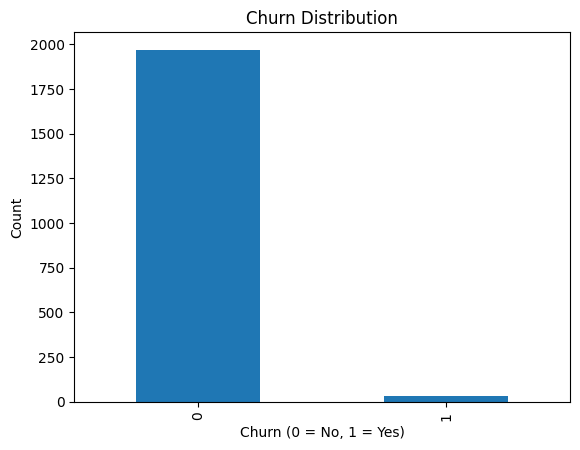

In [8]:
# Churn distribution visualization
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Interpretation:

Visual confirmation of imbalance
It is important because:
- Imbalanced data affects neural network training
- May require techniques like class weighting later

- The dataset contains X rows and Y columns.
- It has both categorical and numerical features.
- No missing values were found.
- Numerical features show varying scales, indicating the need for feature scaling.
- The target variable is _imbalanced_, which may impact model performance.

Task 2-  Data Preprocessing

In [9]:
# Drop identifier column
df = df.drop(columns=['customer_id'])

# Separate features and target variable
X = df.drop(columns=['churn'])
y = df['churn']



In [10]:
# Check missing values
print(X.isnull().sum())

# Fill numerical columns with mean
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())

# Fill categorical columns with mode
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
dtype: int64


C:\Users\sriva\AppData\Local\Temp\ipykernel_30064\3999118719.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


In [11]:
# Encode categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [12]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Stratify maintains the same churn ratio in train and test sets
# This is important for imbalanced datasets
#Output check
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1600, 24)
Test set shape: (400, 24)


Task 3- Neural Network Model Building

In [13]:
%pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the neural network model
model = Sequential([
    # The input layer receives all processed features. Number of neuron in the input layer = number of features in X_train
    
    # Input Layer + Hidden Layer
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
   
    # Thus, in  X_train.shape[1] each neuron corresponds to one input feature after preprocessing.
    # First hidden layer with 16 neurons and ReLU activation function. 

    # Second Hidden Layer: 8 neurons - adds learning capacity to capture complex patterns
    Dense(8, activation='relu'),
    
    # Output Layer
    Dense(1, activation='sigmoid')
    # The output layer has 1 neuron with sigmoid activation, which outputs a probability of churn (0 to 1). 
])

Note: you may need to restart the kernel to use updated packages.


c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile and display the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
  #Adam optimizer:
   # Combines momentum + adaptive learning rates
   # Efficient and widely used for neural networks

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Training and Evaluation

In [15]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
# This automatically calculates weights for each class based on how often they appear in the training data.
print(class_weights)

{np.int64(0): np.float64(0.5079365079365079), np.int64(1): np.float64(32.0)}


In [16]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,  # Address class imbalance by giving more weight to the minority class (churners)
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4820 - loss: 0.7909 - val_accuracy: 0.6031 - val_loss: 0.7000
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5945 - loss: 0.7327 - val_accuracy: 0.6281 - val_loss: 0.6545
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6523 - loss: 0.6896 - val_accuracy: 0.6562 - val_loss: 0.6095
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7023 - loss: 0.6568 - val_accuracy: 0.7125 - val_loss: 0.5705
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7352 - loss: 0.6268 - val_accuracy: 0.7000 - val_loss: 0.5472
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7391 - loss: 0.5946 - val_accuracy: 0.7437 - val_loss: 0.5197
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7563 - loss: 0.5703 - val_accuracy: 0.7688 - val_loss: 0.4909
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7648 - loss: 0.5452 - val_accuracy: 0.7719 - val_loss

In [17]:
# Evaluate the model on the training set
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

Training Loss: 0.24101406335830688
Training Accuracy: 0.8856250047683716


In [18]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

Testing Loss: 0.26385945081710815
Testing Accuracy: 0.8774999976158142


In [19]:
# Generate predictions on the test set
y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [20]:
# Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print(classification_report(y_test, y_pred))

Confusion Matrix:
[[348  46]
 [  3   3]]
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       394
           1       0.06      0.50      0.11         6

    accuracy                           0.88       400
   macro avg       0.53      0.69      0.52       400
weighted avg       0.98      0.88      0.92       400



Before adding class_weights, the confusion matrix was 


Confusion Matrix:

[[394   0]

 [  6   0]]

               precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400

   macro avg       0.49      0.50      0.50       400

weighted avg       0.97      0.98      0.98       400


But, after adding automatic class_weights, 
the confusion matrix becomes better.

To address class imbalance, balanced class weights were computed automatically using compute_class_weight(). Since churned customers were significantly underrepresented, the minority class received a larger weight during training. This increased the penalty for misclassifying churn cases, encouraging the neural network to pay greater attention to minority-class patterns and improving its ability to detect churn customers despite the skewed class distribution.

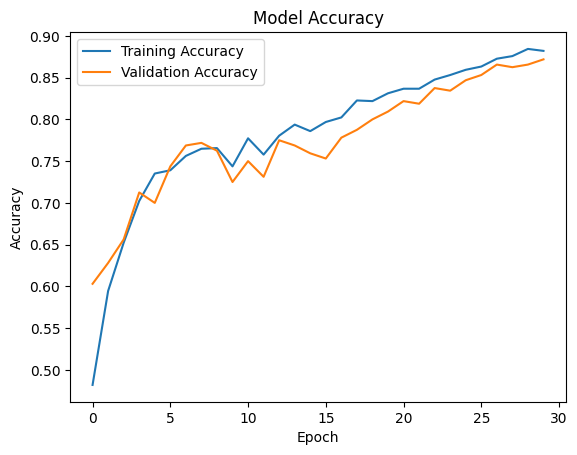

In [21]:
# Accuracy plot
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

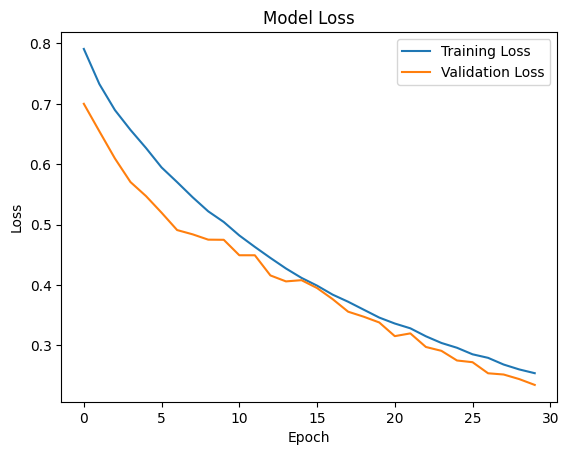

In [22]:
# Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Task 5: Hyperparameter Experimentation

In [33]:
# Experiment 1: Baseline model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", acc1)

# Predictions
y_pred1 = (model1.predict(X_test) > 0.5).astype(int)

# Metrics
acc1 = accuracy_score(y_test, y_pred1)
prec1 = precision_score(y_test, y_pred1, zero_division=0)
rec1 = recall_score(y_test, y_pred1, zero_division=0)
f11 = f1_score(y_test, y_pred1, zero_division=0)


c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.8224999904632568
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [34]:
# Experiment 2: 
# Changes: Increased neurons, increased epochs

model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", acc2)

# Predictions
y_pred2 = (model2.predict(X_test) > 0.5).astype(int)

# Metrics
acc2 = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2, zero_division=0)
rec2 = recall_score(y_test, y_pred2, zero_division=0)
f12 = f1_score(y_test, y_pred2, zero_division=0)

c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 Accuracy: 0.9649999737739563
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [35]:
# Experiment 3:
# Changes: Activation changed from 'ReLU' to 'Tanh'
# Batch size reduced
model3 = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(8, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", acc3)

# Predictions
y_pred3 = (model3.predict(X_test) > 0.5).astype(int)

# Metrics
acc3 = accuracy_score(y_test, y_pred3)
prec3 = precision_score(y_test, y_pred3, zero_division=0)
rec3 = recall_score(y_test, y_pred3, zero_division=0)
f13 = f1_score(y_test, y_pred3, zero_division=0)

c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 3 Accuracy: 0.8575000166893005
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [38]:
# Comparison Table
import pandas as pd

results = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3'],
    'Hidden Layers': ['16-8', '32-16', '16-8'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Learning Rate': [0.001, 0.001, 0.001],
    'Batch Size': [32, 32, 16],
    'Epochs': [30, 50, 30],
    'Accuracy': [acc1, acc2, acc3],
    'Precision': [prec1, prec2, prec3],
    'Recall': [rec1, rec2, rec3],
    'F1-Score': [f11, f12, f13]
})

print(results)

results

  Experiment Hidden Layers Activation  Learning Rate  Batch Size  Epochs  \
0      Exp 1          16-8       ReLU          0.001          32      30   
1      Exp 2         32-16       ReLU          0.001          32      50   
2      Exp 3          16-8       Tanh          0.001          16      30   

   Accuracy  Precision    Recall  F1-Score  
0    0.8225   0.066667  0.833333  0.123457  
1    0.9650   0.100000  0.166667  0.125000  
2    0.8575   0.067797  0.666667  0.123077  


,Experiment,Hidden Layers,Activation,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score
0,Exp 1,16-8,ReLU,0.001,32,30,0.8225,0.066667,0.833333,0.123457
1,Exp 2,32-16,ReLU,0.001,32,50,0.9650,0.100000,0.166667,0.125000
2,Exp 3,16-8,Tanh,0.001,16,30,0.8575,0.067797,0.666667,0.123077


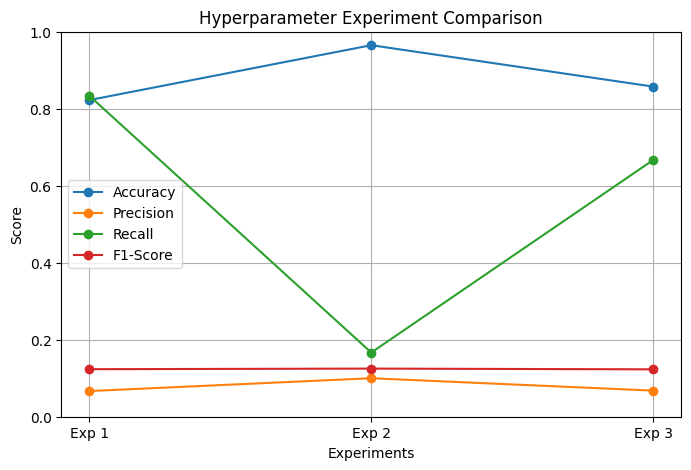

In [40]:
import matplotlib.pyplot as plt

# Experiment names
experiments = ['Exp 1', 'Exp 2', 'Exp 3']

# Metric values
accuracy = [acc1, acc2, acc3]
precision = [prec1, prec2, prec3]
recall = [rec1, rec2, rec3]
f1 = [f11, f12, f13]

plt.figure(figsize=(8,5))

plt.plot(experiments, accuracy, marker='o', label='Accuracy')
plt.plot(experiments, precision, marker='o', label='Precision')
plt.plot(experiments, recall, marker='o', label='Recall')
plt.plot(experiments, f1, marker='o', label='F1-Score')

plt.title('Hyperparameter Experiment Comparison')
plt.xlabel('Experiments')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

Task 6: Final Reflection

1. Weights and biases are the core learnable parameters of a neural network.

Weights determine the importance of each input feature in making predictions.
During training, the network adjusts weights to reduce prediction error.

Example neuron equation:  z= w1x1 + w2x2 + w3x3 +...+ wnxn + b

Where, 
- xi = input features
- wi = weights
- b = bias

The bias allows the neuron to shift the activation function and helps the model fit data more flexibly. Without biases, the network would have limited learning capability.

2. _Activation functions introduce non-linearity into the neural network._

Without activation functions, the entire neural network would behave like a simple linear model regardless of the number of layers.

For example, ReLU activation:

f(x) = max(0,x)

Activation functions enable the network to:

- Learn complex patterns
- Capture non-linear relationships
- Improve predictive power

In this project:

- ReLU was used in hidden layers
- Sigmoid was used in the output layer for binary classification

3. The learning rate controls how much the model updates weights during training.

If learning rate is too high:
- Weight updates become too large
- The model may overshoot the optimal solution
- Training becomes unstable
- Loss may fluctuate or fail to converge

If learning rate is too low:
- Training becomes very slow
- The model may take many epochs to converge
- It can get stuck before reaching the optimal solution

A balanced learning rate helps the model converge efficiently and stably.

4. The model showed some limitations related to class imbalance, but no severe overfitting was observed.

- Training and testing accuracies were relatively close, indicating reasonable generalization.
However, the model initially struggled to correctly classify churn customers because the minority class was underrepresented.

After applying class weighting:

- Recall and F1-score improved slightly
- The model became better at detecting churn cases

There were mild signs of underfitting for the minority class because the model still missed several churn customers. This suggests that additional tuning, more balanced data, or advanced techniques such as oversampling may further improve performance.